In [1]:
import functools
import warnings

import botocore
import boto3
from iterpop import iterpop as ip
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import pandas as pd
from pandas.util import hash_pandas_object
from scipy import stats as scipy_stats
import seaborn as sns
from teeplot import teeplot as tp
from tqdm import tqdm

from dishpylib.pyhelpers import fit_control_t_distns

warnings.filterwarnings("ignore")


In [2]:
from dishpylib.pyhelpers import print_runtime


In [3]:
print_runtime()


context: ci
hostname: runnervm08nci
interpreter: 3.10.12 (main, Mar  3 2026, 11:56:32) [GCC 11.4.0]
notebook name: 2026-06-18-multistint-complexity
notebook path: /home/runner/work/oee4/oee4/binder/2026-06-18-multistint-complexity.ipynb
revision: bdac574
timestamp: 2026-06-22T20:21:29Z00:00

IPython==7.16.1
packaging==26.0


In [4]:
teeplot_subdir = "2026-06-18-multistint-complexity"


In [5]:
@functools.lru_cache
def get_control_t_distns( bucket, prefix, endeavor, stint ):

    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    control_competitions, = bucket_handle.objects.filter(
        Prefix=f'endeavor={endeavor}/{prefix}control-competitions/stage={2 + bool(prefix)}+what=collated/stint={stint}/',
    )

    control_df = pd.read_csv(
        f's3://{bucket}/{control_competitions.key}',
    )

    return fit_control_t_distns(control_df[
        control_df["Root ID"] == 1
    ].copy())


In [6]:
def preprocess_competition_fitnesses(competitions_df, control_fits_df):
    print(len(competitions_df), "competitions to preprocess")
    print(len(control_fits_df), "control fits available")
    # preprocess data
    @functools.lru_cache
    def h0_fit(series):
        return ip.popsingleton(
            control_fits_df[control_fits_df["Series"] == series].to_dict(
                orient="records",
            )
        )

    competitions_df["p"] = competitions_df.apply(
        lambda row: scipy_stats.t.cdf(
            row["Fitness Differential"],
            h0_fit(row["genome series"])["Fit Degrees of Freedom"],
            loc=h0_fit(row["genome series"])["Fit Loc"],
            scale=h0_fit(row["genome series"])["Fit Scale"],
        ),
        axis=1,
    )
    competitions_df["Is Less Fit"] = competitions_df["p"] < 1.0 / 40
    competitions_df["Is More Fit"] = competitions_df["p"] > (1.0 -  1.0 / 40)
    competitions_df["Is Neutral"] = ~(
        competitions_df["Is Less Fit"] | competitions_df["Is More Fit"]
    )
    competitions_df["Relative Fitness"] = competitions_df.apply(
        lambda row: (
            "Significantly Advantageous"
            if row["Is More Fit"]
            else (
                "Significantly Deleterious" if row["Is Less Fit"] else "Neutral"
            )
        ),
        axis=1,
    )

    return competitions_df


# get data


In [7]:
prefix = ""
dfs = []
for bucket, stint in [
    ("prq49", 20),
    ("prq49", 40),
    ("prq49-20stint", 0),
    ("prq49-40stint", 0),
]:
    endeavor = {
        "prq49": 16,
        "prq49-20stint": 17,
        "prq49-40stint": 18,
    }[bucket]

    if "step" in bucket:
        step = int(bucket.split("-step")[-1]) + 1
    else:
        step = 0
    if "restint" in bucket:
        kind = bucket.split("-")[3]
    else:
        kind = None
    s3_handle = boto3.resource(
        's3',
        region_name="us-east-2",
        config=botocore.config.Config(
            signature_version=botocore.UNSIGNED,
        ),
    )
    bucket_handle = s3_handle.Bucket(bucket)

    try:
        series_profiles, = bucket_handle.objects.filter(
            Prefix=f'endeavor={endeavor}/{prefix}variant-competitions/stage=3+what=collated/stint={stint}/',
        )
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
        control_fits_df = get_control_t_distns(bucket, prefix, endeavor, stint)
        df = pd.read_csv(
            f's3://{bucket}/{series_profiles.key}',
            compression='xz',
        )
        # df = df[df["Competition Series"] == 16005]
        # df = df.groupby([
        #     "genome variation"
        # ]).mean(numeric_only=True).reset_index()
        df["Stint"] = stint
        df["Series"] = df["Competition Series"]
        dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
        df = preprocess_competition_fitnesses(df, control_fits_df)
        assert "Series" in df.columns, df.columns

        df = df.copy()
        df["bucket"] = bucket
        df["kind"] = "genotype"
        df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
        dfs.append(df)
    except Exception as e:
        print(e)
        print(f"Skipping {bucket=}, {stint=}, {prefix=}")


    for what in [
        "perturbation-extrospective-state-exchange-competitions",
        # "perturbation-extrospective-state-rotate-competitions",
        "perturbation-introspective-state-exchange-competitions",
        # "perturbation-introspective-state-rotate-competitions",
        "perturbation-writable-state-exchange-competitions",
        # "perturbation-writable-state-rotate-competitions",
        "selfsend-inter-competitions",
        "selfsend-intra-competitions",
    ]:
        try:
            series_profiles, = bucket_handle.objects.filter(
                Prefix=f'endeavor={endeavor}/{what}/stage=2+what=collated/stint={stint}/',
            )
            import warnings
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
            control_fits_df = get_control_t_distns(bucket, prefix, endeavor, stint)
            df = pd.read_csv(
                f's3://{bucket}/{series_profiles.key}',
                compression='xz',
            )
            df["Stint"] = stint
            df["Series"] = df["Competition Series"]
            dfdigest = "{:x}".format( hash_pandas_object( df ).sum() )
            df = preprocess_competition_fitnesses(df, control_fits_df)
            assert "Series" in df.columns, df.columns

            df = df.copy()
            df["bucket"] = bucket
            df["variant"] = {"cryptic-": "skeleton", "": "wildtype"}[prefix]
            df["what"] = what
            df["kind"] = "phenotype"

            dfs.append(df)
        except Exception as e:
            print(e)
            print(f"Skipping {bucket=}, {stint=}, {prefix=}")


10714 competitions to preprocess
40 control fits available
4960 competitions to preprocess
40 control fits available
3520 competitions to preprocess
40 control fits available
1440 competitions to preprocess
40 control fits available
1600 competitions to preprocess
40 control fits available
1600 competitions to preprocess
40 control fits available
18210 competitions to preprocess
40 control fits available
4960 competitions to preprocess
40 control fits available
3520 competitions to preprocess
40 control fits available
1440 competitions to preprocess
40 control fits available
1600 competitions to preprocess
40 control fits available
1600 competitions to preprocess
40 control fits available
6742 competitions to preprocess
40 control fits available
4960 competitions to preprocess
40 control fits available
3516 competitions to preprocess
40 control fits available
1440 competitions to preprocess
40 control fits available
1600 competitions to preprocess
40 control fits available
1600 competi

In [8]:
df = pd.concat(dfs)


In [9]:
pd.options.display.max_columns = None


In [10]:
dfxx = df[
    df["Root ID"] == 1
].groupby(["Series", "Stint", "bucket", "variant", "kind"]).agg(
    {
        "Is More Fit": "sum",
        "Is Less Fit": "sum",
        "Is Neutral": "sum",
        "genome variation": "count",
    },
)
dfxx


Is More Fit  Is Less Fit  \
Series Stint bucket        variant  kind                                  
16000  20    prq49         wildtype genotype            12           14   
                                    phenotype            1            5   
       40    prq49         wildtype genotype             2           28   
                                    phenotype            2            5   
16001  20    prq49         wildtype genotype             0           11   
...                                                    ...          ...   
18037  0     prq49-40stint wildtype phenotype            3            5   
18038  0     prq49-40stint wildtype genotype            21            6   
                                    phenotype           13            2   
18039  0     prq49-40stint wildtype genotype             4           22   
                                    phenotype            1            7   

                                               Is Neutral  genome variation  
Series Stint bucket        variant  kind                                     
16000  20    prq49         wildtype genotype          188               214  
                                    phenotype         158               164  
       40    prq49         wildtype genotype          385               415  
                                    phenotype         157               164  
16001  20    prq49         wildtype genotype           32                43  
...                                                   ...               ...  
18037  0     prq49-40stint wildtype phenotype         156               164  
18038  0     prq49-40stint wildtype genotype           20                47  
                                    phenotype         149               164  
18039  0     prq49-40stint wildtype genotype           55                81  
                                    phenotype         156               164  

[319 rows x 4 columns]

In [11]:
dfxx = dfxx.reset_index(drop=False)


In [12]:
dfxx["bucket-stint"] = dfxx["bucket"] + "-stint" + dfxx["Stint"].astype(str)


teeplots/col=bucket-stint+hue=kind+style=kind+viz=relplot+x=series+y=is-more-fit+ext=.pdf
teeplots/col=bucket-stint+hue=kind+style=kind+viz=relplot+x=series+y=is-more-fit+ext=.png


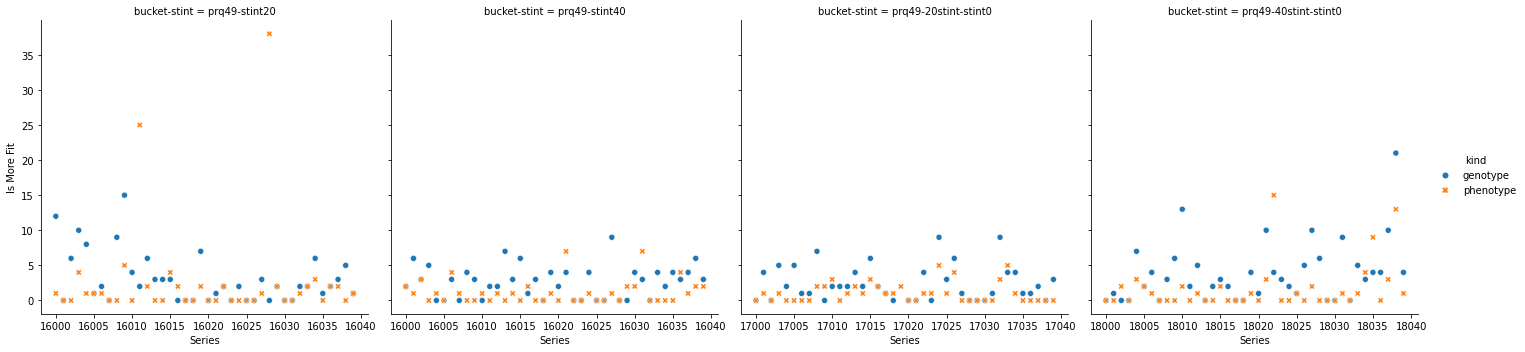

teeplots/col=bucket-stint+hue=kind+style=kind+viz=relplot+x=series+y=is-less-fit+ext=.pdf
teeplots/col=bucket-stint+hue=kind+style=kind+viz=relplot+x=series+y=is-less-fit+ext=.png


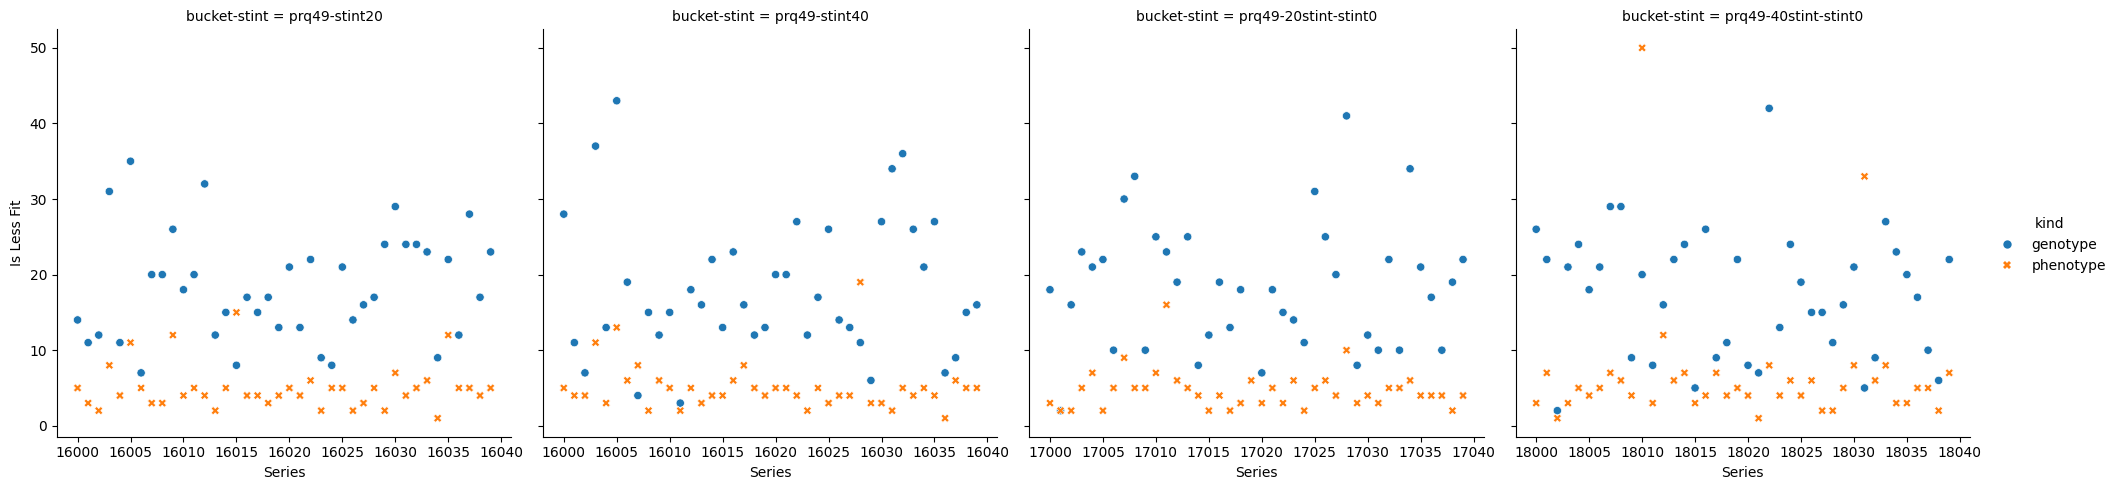

In [13]:
for y in ["Is More Fit", "Is Less Fit"]:
    with tp.teed(
        sns.relplot,
        data=dfxx,
        x="Series",
        y=y,
        col="bucket-stint",
        hue="kind",
        style="kind",
        markers=True,
        dashes=False,
        facet_kws=dict(sharex=False),
    ) as _:
        pass


teeplots/col=bucket-stint+kind=scatter+viz=relplot+x=phenotype+y=genotype+ext=.pdf
teeplots/col=bucket-stint+kind=scatter+viz=relplot+x=phenotype+y=genotype+ext=.png


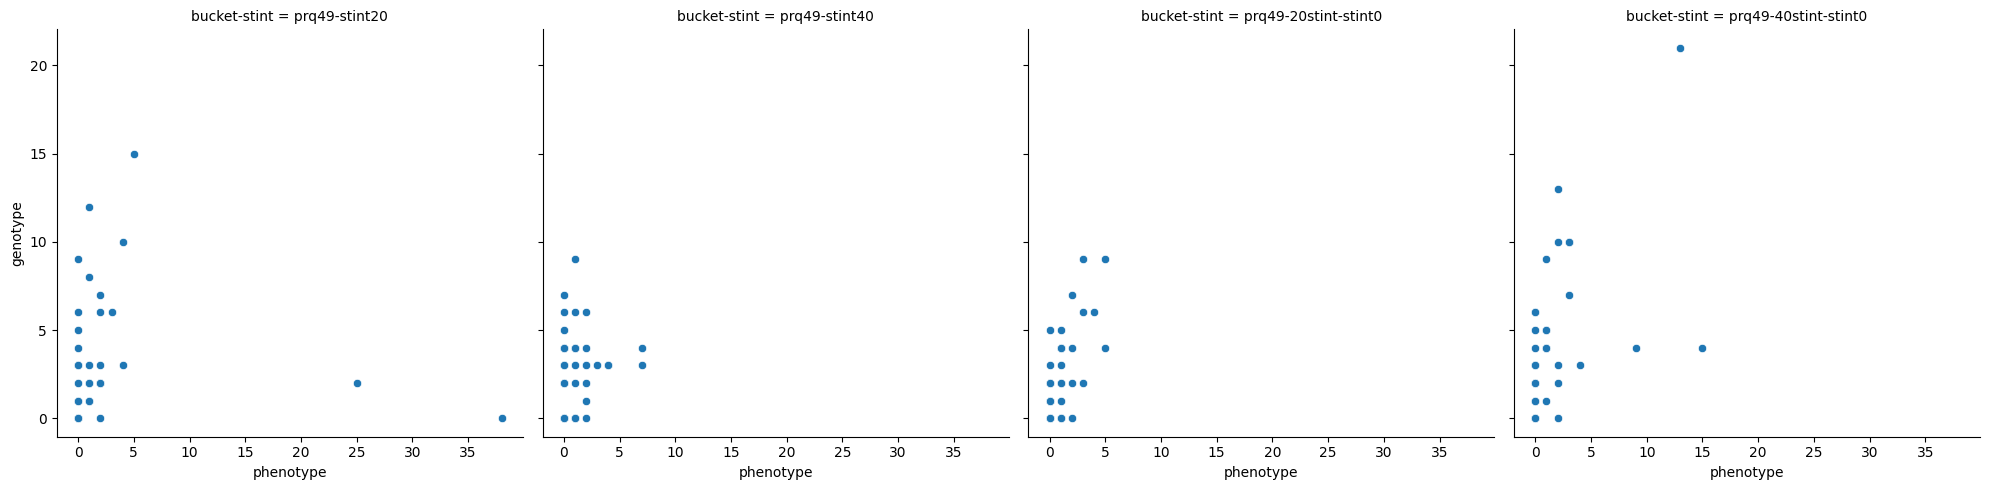

teeplots/col=bucket-stint+kind=scatter+viz=relplot+x=phenotype+y=genotype+ext=.pdf
teeplots/col=bucket-stint+kind=scatter+viz=relplot+x=phenotype+y=genotype+ext=.png


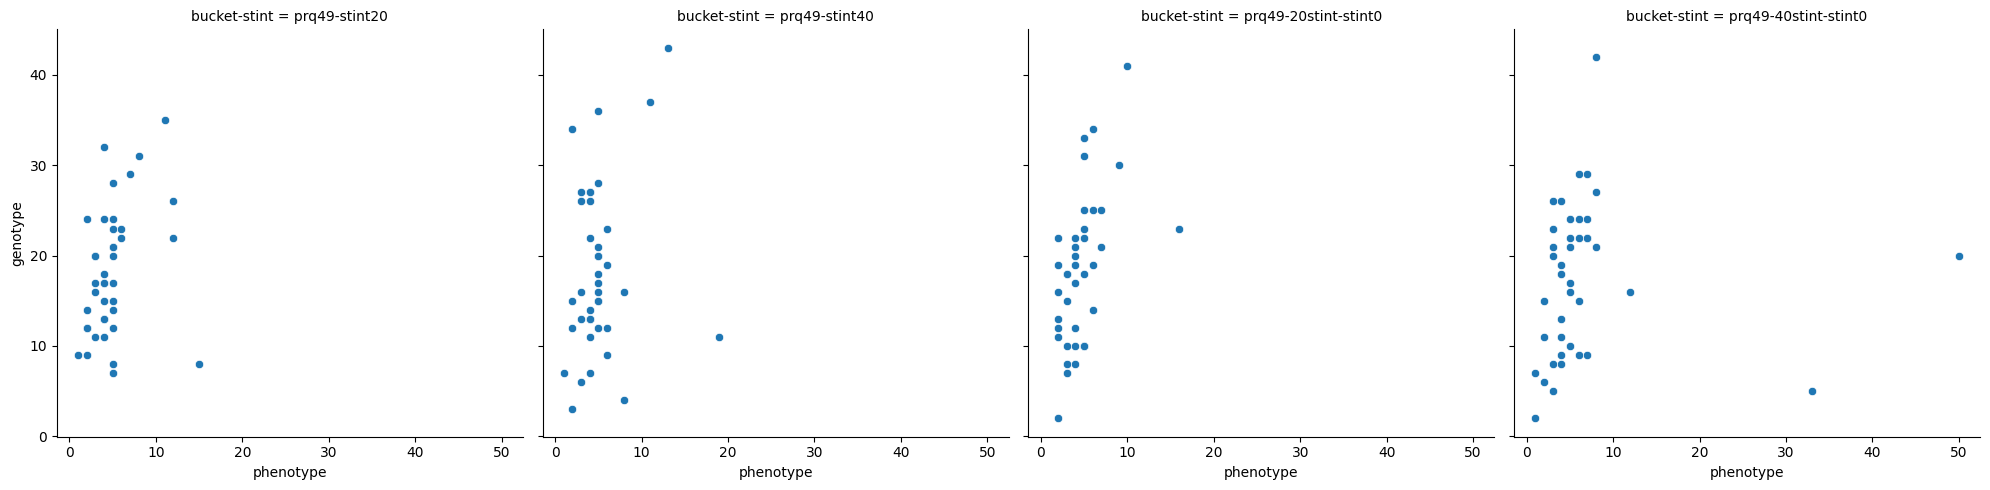

In [14]:
for y in ["Is More Fit", "Is Less Fit"]:

    # 1. Pivot the dataframe so that 'phenotype' and 'genotype' become columns
    # where the values inside are derived from the current 'y' metric
    df_wide = dfxx.pivot_table(
        index=["Series", "bucket-stint"],
        columns="kind",
        values=y
    ).reset_index()

    # 2. Plot the scatter
    with tp.teed(
        sns.relplot,
        data=df_wide,
        x="phenotype",  # Assuming 'phenotype' is the exact string in the 'kind' column
        y="genotype",   # Assuming 'genotype' is the exact string in the 'kind' column
        col="bucket-stint",
        kind="scatter",
        facet_kws=dict(sharex=True, sharey=True),
    ) as _:
        pass


teeplots/hue=bucket-stint+kind=genotype+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=genotype+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.png


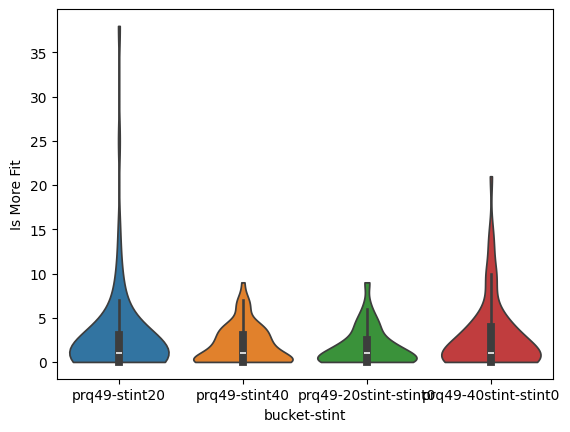

teeplots/hue=bucket-stint+kind=phenotype+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=phenotype+viz=violinplot+x=bucket-stint+y=is-more-fit+ext=.png


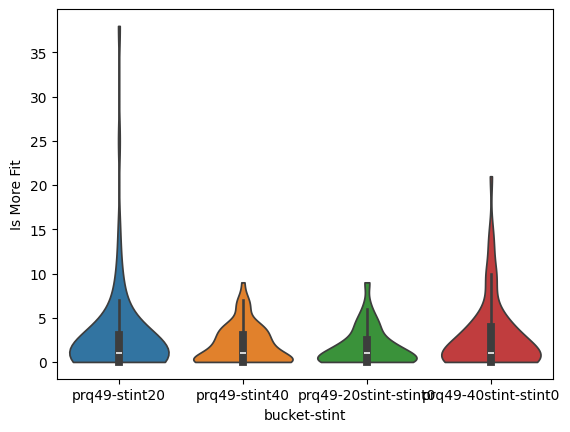

teeplots/hue=bucket-stint+kind=genotype+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=genotype+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.png


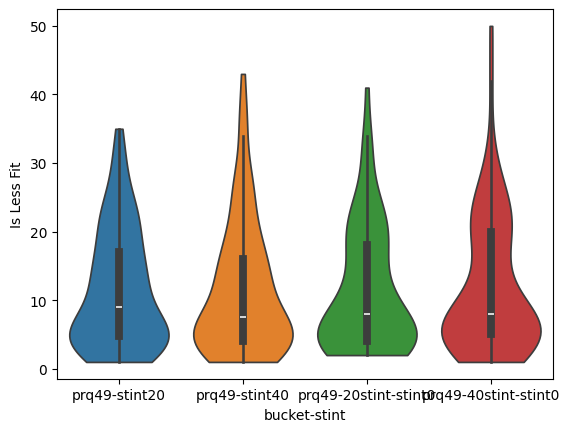

teeplots/hue=bucket-stint+kind=phenotype+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=phenotype+viz=violinplot+x=bucket-stint+y=is-less-fit+ext=.png


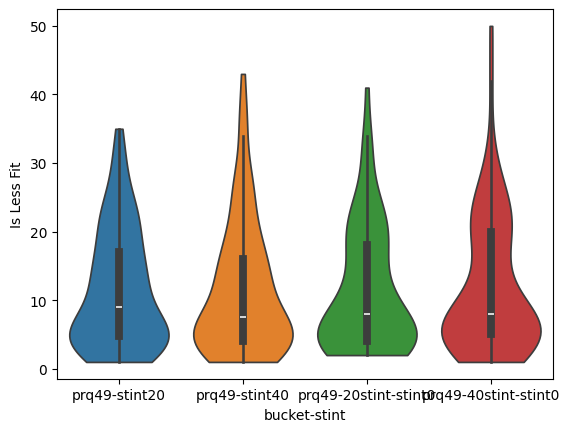

In [15]:
for y in ["Is More Fit", "Is Less Fit"]:
    for kind in dfxx["kind"].unique():
        with tp.teed(
            sns.violinplot,
            data=dfxx,
            y=y,
            hue="bucket-stint",
            x="bucket-stint",
            cut=0,
            teeplot_outattrs=dict(kind=kind),
        ) as _:
            pass


teeplots/hue=bucket-stint+kind=genotype+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=genotype+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.png


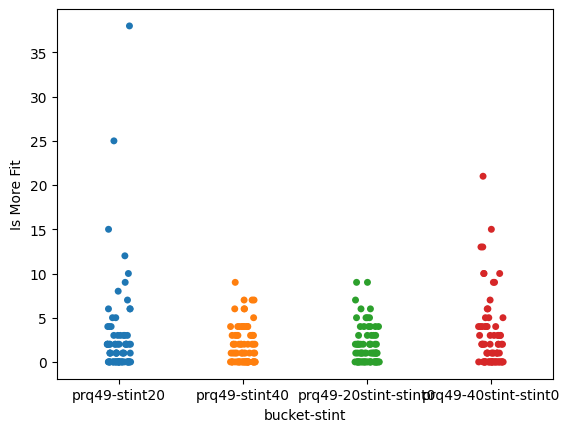

teeplots/hue=bucket-stint+kind=phenotype+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=phenotype+viz=stripplot+x=bucket-stint+y=is-more-fit+ext=.png


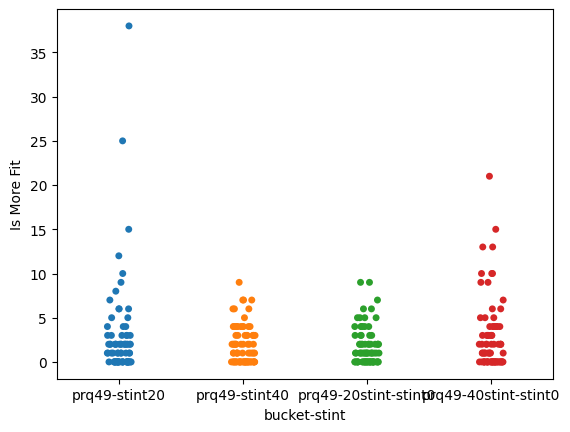

teeplots/hue=bucket-stint+kind=genotype+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=genotype+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.png


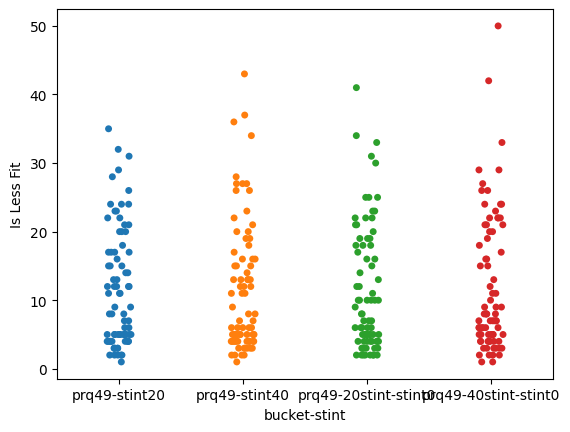

teeplots/hue=bucket-stint+kind=phenotype+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.pdf
teeplots/hue=bucket-stint+kind=phenotype+viz=stripplot+x=bucket-stint+y=is-less-fit+ext=.png


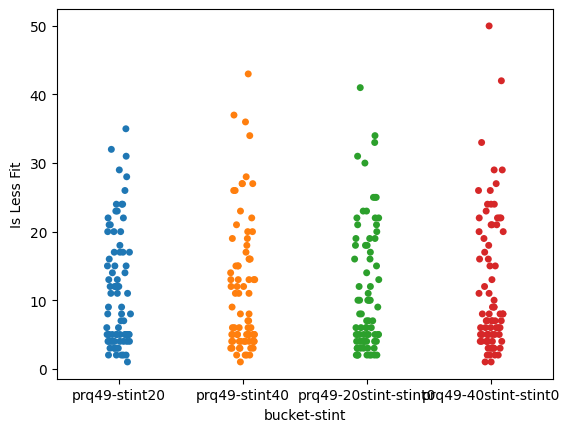

In [16]:
for y in ["Is More Fit", "Is Less Fit"]:
    for kind in dfxx["kind"].unique():
        with tp.teed(
            sns.stripplot,
            data=dfxx,
            y=y,
            hue="bucket-stint",
            x="bucket-stint",
            teeplot_outattrs=dict(kind=kind),
        ) as _:
            pass
